### No preprocessing

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('../dataset/full.csv')
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [9]:
predictor_list = df.columns.difference(['Activity', 'Subject'])  # Exclude target and group columns
X = df[predictor_list]  # Predictors (69 components)
y = df["Activity"]                        # Target variable
groups = df["subject"]

In [10]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

# Get indices for train and test sets based on Subject groups
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

train_subjects = sorted(groups_train.unique())
test_subjects = sorted(groups_test.unique())

print("Subjects in training data:")
print(train_subjects)

print("\nSubjects in test data:")
print(test_subjects)

print("\nNumber of training subjects:", len(train_subjects))
print("Number of test subjects:", len(test_subjects))

overlap = set(train_subjects) & set(test_subjects)
print("\nOverlapping subjects:", overlap)

Subjects in training data:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(17), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(26), np.int64(27), np.int64(30)]

Subjects in test data:
[np.int64(9), np.int64(10), np.int64(16), np.int64(18), np.int64(24), np.int64(25), np.int64(28), np.int64(29)]

Number of training subjects: 22
Number of test subjects: 8

Overlapping subjects: set()


In [ ]:
# Initialize and train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

model = XGBClassifier(
    n_estimators=100,     # Number of boosting rounds (trees)
    max_depth=4,          # Maximum tree depth
    learning_rate=0.1,    # Step size shrinkage (eta) to prevent overfitting
    objective='binary:logistic', # Loss function for binary classification
    random_state=42
)

# Evaluate on unseen subjects
y_pred = model.predict(X_test)

print("--- Classification Report (Unseen Subjects) ---")
print(classification_report(y_test, y_pred))

--- Classification Report (Unseen Subjects) ---
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.76      0.83      0.79       495
          STANDING       0.81      0.76      0.78       527
           WALKING       0.97      0.99      0.98       451
WALKING_DOWNSTAIRS       0.97      0.78      0.87       389
  WALKING_UPSTAIRS       0.83      0.95      0.89       429

          accuracy                           0.88      2828
         macro avg       0.89      0.88      0.88      2828
      weighted avg       0.89      0.88      0.88      2828



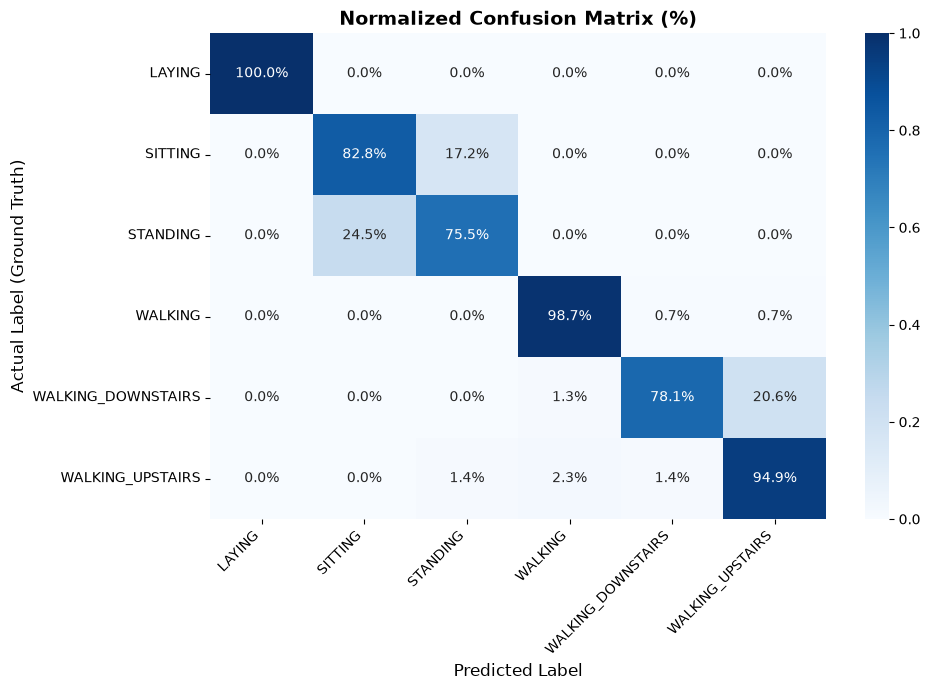

In [6]:
# Compute normalized matrix (percentages along rows)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# 2. Get unique activity labels in alphabetical order (matching confusion_matrix default)
labels = sorted(y_test.unique())

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.1%',              # Format as percentage (e.g., 70.2%)
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels
)

plt.title('Normalized Confusion Matrix (%)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()